<a href="https://colab.research.google.com/github/andrei0182/New-York-Housing-Market-Analysis/blob/main/analiza_ny_houses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Totul e instalat!")

✅ Totul e instalat!


In [ ]:
import os

# Token-ul tău Kaggle
os.environ['KAGGLE_USERNAME'] = 'andrei0182'
os.environ['KAGGLE_KEY'] = 'KGAT_5e7a6737b009823ddc53f5d527be62cd'

# Instalăm kaggle
!pip install kaggle -q

# Descărcăm datasetul
!kaggle datasets download -d nelgiriyewithana/new-york-housing-market

# Dezarhivăm
!unzip new-york-housing-market.zip

print("✅ Dataset descărcat!")

Dataset URL: https://www.kaggle.com/datasets/nelgiriyewithana/new-york-housing-market
License(s): other
100% 271k/271k [00:00<00:00, 85.2MB/s]

Archive:  new-york-housing-market.zip
  inflating: NY-House-Dataset.csv    
✅ Dataset descărcat!


In [ ]:
df = pd.read_csv('NY-House-Dataset.csv')
print(df.shape)
print(df.head())

(4801, 17)
                                         BROKERTITLE                TYPE  \
0        Brokered by Douglas Elliman  -111 Fifth Ave      Condo for sale   
1                                Brokered by Serhant      Condo for sale   
2                             Brokered by Sowae Corp      House for sale   
3                                Brokered by COMPASS      Condo for sale   
4  Brokered by Sotheby's International Realty - E...  Townhouse for sale   

       PRICE  BEDS       BATH  PROPERTYSQFT  \
0     315000     2   2.000000        1400.0   
1  195000000     7  10.000000       17545.0   
2     260000     4   2.000000        2015.0   
3      69000     3   1.000000         445.0   
4   55000000     7   2.373861       14175.0   

                                             ADDRESS                    STATE  \
0                               2 E 55th St Unit 803       New York, NY 10022   
1  Central Park Tower Penthouse-217 W 57th New Yo...       New York, NY 10019   
2     

In [6]:
# Statistici generale
print("=== Statistici prețuri ===")
print(df['PRICE'].describe())

# Preț mediu per tip proprietate
print("\n=== Preț mediu per tip ===")
print(df.groupby('TYPE')['PRICE'].mean().sort_values(ascending=False))

# Cel mai scump tip
cel_mai_scump = df.groupby('TYPE')['PRICE'].mean().idxmax()
print(f"\n🏆 Cel mai scump tip: {cel_mai_scump}")

=== Statistici prețuri ===
count    4.801000e+03
mean     2.356940e+06
std      3.135525e+07
min      2.494000e+03
25%      4.990000e+05
50%      8.250000e+05
75%      1.495000e+06
max      2.147484e+09
Name: PRICE, dtype: float64

=== Preț mediu per tip ===
TYPE
Townhouse for sale            6.365925e+06
House for sale                3.684216e+06
Condo for sale                2.630710e+06
For sale                      1.954536e+06
Multi-family home for sale    1.680428e+06
Foreclosure                   1.343010e+06
Pending                       1.340867e+06
Mobile house for sale         1.288000e+06
Coming Soon                   1.172000e+06
Co-op for sale                1.100418e+06
Land for sale                 1.073021e+06
Condop for sale               9.986000e+05
Contingent                    8.825717e+05
Name: PRICE, dtype: float64

🏆 Cel mai scump tip: Townhouse for sale


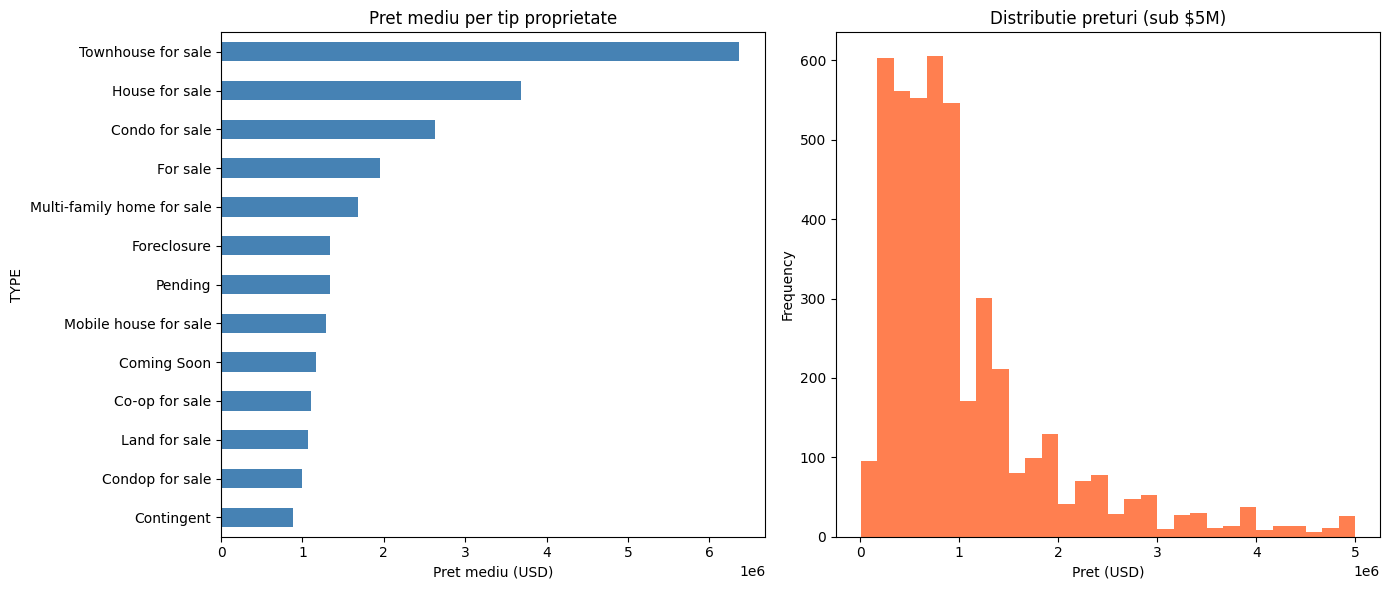

✅ Grafic salvat!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafic 1 - Pret mediu per tip
pret_tip = df.groupby('TYPE')['PRICE'].mean().sort_values()
pret_tip.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Pret mediu per tip proprietate')
axes[0].set_xlabel('Pret mediu (USD)')

# Grafic 2 - Distributie preturi
df[df['PRICE'] < 5000000]['PRICE'].plot(
    kind='hist', ax=axes[1],
    bins=30, color='coral'
)
axes[1].set_title('Distributie preturi (sub $5M)')
axes[1].set_xlabel('Pret (USD)')

plt.tight_layout()
plt.savefig('ny_houses.png', dpi=150)
plt.show()
print("✅ Grafic salvat!")